# VGG_NET16 $\Gamma$

Saved /Users/zd3504phd/Desktop/XAIV/plots/5.3.1_gamma/vggnet_gamma_all_option1.csv
Saved /Users/zd3504phd/Desktop/XAIV/plots/5.3.1_gamma/vggnet_gamma_all_option1_sorted.csv

Counts:
  images: 182
  gamma_defined: 88
  missing_Lg: 94
  missing_Lo: 94
  missing_Lb: 94
  imputed_any: 0
  phi_fail: 0


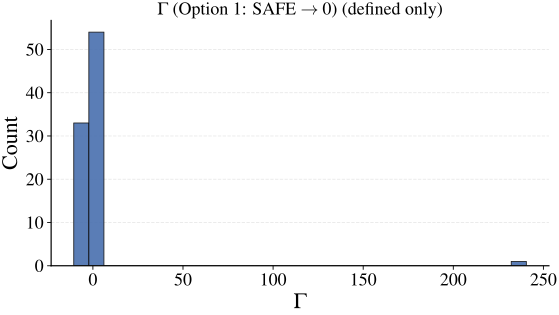

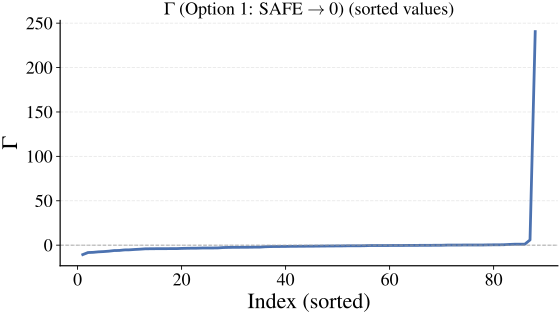

In [12]:
import glob
import os
import re
import shutil
import subprocess
from pathlib import Path


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "results" / "vggnet16" / "ALL_vggnet.csv").exists() and (candidate / "benchmarks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the XAIV project root from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
PLOT_DIR = PROJECT_ROOT / "plots" / "5.3.1_gamma"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_ROOT = PLOT_DIR / ".cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_ROOT / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

texlive_root = Path("/opt/homebrew/Cellar/texlive")
tex_bin_candidates = [
    Path("/opt/homebrew/opt/texlive/bin"),
    *sorted(texlive_root.glob("*/bin"), reverse=True),
    Path("/opt/homebrew/bin"),
    Path("/Library/TeX/texbin"),
    Path("/usr/texbin"),
]
tex_lib_candidates = [
    Path("/opt/homebrew/opt/libpng/lib"),
    Path("/opt/homebrew/opt/texlive/lib"),
    *sorted(texlive_root.glob("*/lib"), reverse=True),
]

current_path = os.environ.get("PATH", "")
path_parts = current_path.split(":") if current_path else []
for texbin in tex_bin_candidates:
    if texbin.exists():
        texbin_str = str(texbin)
        if texbin_str not in path_parts:
            path_parts.insert(0, texbin_str)
os.environ["PATH"] = ":".join(path_parts)

current_dyld = os.environ.get("DYLD_LIBRARY_PATH", "")
dyld_parts = current_dyld.split(":") if current_dyld else []
for texlib in tex_lib_candidates:
    if texlib.exists():
        texlib_str = str(texlib)
        if texlib_str not in dyld_parts:
            dyld_parts.insert(0, texlib_str)
if dyld_parts:
    os.environ["DYLD_LIBRARY_PATH"] = ":".join(dyld_parts)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
from PIL import Image

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
except ImportError:
    set_matplotlib_formats = None


# -------------------------
# PATHS
# -------------------------
CSV_PATH = PROJECT_ROOT / "results" / "vggnet16" / "ALL_vggnet.csv"
ONNX_BASE_DIR = PROJECT_ROOT / "benchmarks" / "vggnet16_benchmark2022"
IMAGE_DIR_CANDIDATES = [
    PROJECT_ROOT / "benchmarks" / "vggnet16_benchmark2022" / "imagenet-sample",
    PROJECT_ROOT / "benchmarks" / "vggnet16_benchmark2022" / "vggnet16_benchmark2022",
]
IMAGE_DIR = next((p for p in IMAGE_DIR_CANDIDATES if p.exists()), IMAGE_DIR_CANDIDATES[0])

OUT_ALL = PLOT_DIR / "vggnet_gamma_all_option1.csv"
OUT_SORTED = PLOT_DIR / "vggnet_gamma_all_option1_sorted.csv"

# -------------------------
# POLICY SWITCHES
# -------------------------
SAFE_TO_ZERO = True
FILL_MISSING_L_WITH_ZERO_FOR_ALL_RESULTS = False

# -------------------------
# Plot settings
# -------------------------
FORCE_TEX = True
HIST_BINS = 30
HIST_COLOR = "#4C72B0"
LINE_COLOR = "#4C72B0"
GRID_ALPHA = 0.30
HIST_FIGSIZE = (8.2, 4.8)
CURVE_FIGSIZE = (8.2, 4.8)
GAMMA_LABEL = r"$\Gamma$"
OUTPUT_COLUMNS = [
    "image",
    "seg_index",
    "model",
    "onnx",
    "img_path",
    "phi",
    "yhat",
    "L_global",
    "L_global_src",
    "global_result",
    "L_global_imputed",
    "L_object",
    "L_object_src",
    "object_result",
    "L_object_imputed",
    "L_background",
    "L_background_src",
    "background_result",
    "L_background_imputed",
    "Gamma",
    "Gamma_defined",
]


# -------------------------
# Helpers
# -------------------------
def latex_ready():
    has_renderer = shutil.which("dvipng") is not None or shutil.which("dvisvgm") is not None
    return shutil.which("latex") is not None and has_renderer


def has_tex_package(package_name):
    if shutil.which("kpsewhich") is None:
        return False
    return subprocess.run(
        ["kpsewhich", f"{package_name}.sty"],
        capture_output=True,
        text=True,
        check=False,
    ).returncode == 0


def running_inside_notebook() -> bool:
    try:
        from IPython import get_ipython
    except ImportError:
        return False

    shell = get_ipython()
    return shell is not None and shell.__class__.__name__ == "ZMQInteractiveShell"


def configure_plot_style(force_tex=FORCE_TEX):
    use_tex = force_tex and latex_ready()
    preamble = r"\usepackage{fontawesome5}" if use_tex and has_tex_package("fontawesome5") else ""

    if set_matplotlib_formats is not None and running_inside_notebook():
        try:
            if use_tex and shutil.which("dvisvgm") is not None:
                set_matplotlib_formats("svg")
            else:
                set_matplotlib_formats("png")
        except Exception:
            pass

    if force_tex and not use_tex:
        print("LaTeX was requested but no compatible renderer was found. Falling back to Matplotlib serif text.")

    mpl.rcParams.update({
        "text.usetex": use_tex,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "text.latex.preamble": preamble,
        "font.size": 16,
        "axes.labelsize": 22,
        "axes.titlesize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 16,
        "axes.linewidth": 1.2,
        "grid.linewidth": 0.9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    return use_tex


def _to_abs_path(maybe_rel, base_dir: Path) -> Path:
    path = Path(str(maybe_rel).strip())
    if path.is_absolute():
        return path
    return (base_dir / path).resolve()


def find_image_file(image_id: str, image_dir: Path) -> str:
    exts = ["png", "PNG", "jpg", "JPG", "jpeg", "JPEG", "bmp", "BMP", "webp", "WEBP", "npy"]
    image_id = str(image_id)
    image_dir = str(image_dir)

    def collect(key):
        out = []
        for ext in exts:
            out += glob.glob(os.path.join(image_dir, f"{key}*.{ext}"))
            out += glob.glob(os.path.join(image_dir, f"*{key}*.{ext}"))
        return out

    cands = collect(image_id)

    m_label = re.search(r"(?:^|__)label_(\d+)(?:__|$)", image_id)
    m_idx = re.search(r"(?:^|__)idx_(\d+)(?:__|$)", image_id)
    if m_label and m_idx:
        cands += collect(f"label_{m_label.group(1)}__idx_{m_idx.group(1)}")

    cands = sorted(set(cands), key=lambda p: (len(os.path.basename(p)), p))
    if not cands:
        raise FileNotFoundError(f"Image not found for '{image_id}' in {image_dir}")
    return cands[0]


def load_rgb_float01(path: str) -> np.ndarray:
    if path.lower().endswith(".npy"):
        arr = np.load(path)
        arr = np.array(arr)
        if arr.ndim == 4:
            arr = arr[0]
        if arr.ndim == 3 and arr.shape[0] == 3 and arr.shape[-1] != 3:
            arr = np.transpose(arr, (1, 2, 0))
        if arr.max() > 1.5:
            arr = arr / 255.0
        return arr.astype(np.float32)

    img = Image.open(path).convert("RGB")
    return (np.asarray(img).astype(np.float32) / 255.0).astype(np.float32)


def _shape_dim_to_int_or_none(d):
    return int(d) if isinstance(d, (int, np.integer)) else None


def infer_layout_from_onnx_input(sess: ort.InferenceSession) -> str:
    shp = sess.get_inputs()[0].shape
    shp_i = [_shape_dim_to_int_or_none(x) for x in shp]
    if len(shp_i) == 4:
        if shp_i[1] == 3:
            return "NCHW"
        if shp_i[3] == 3:
            return "NHWC"
    return "NCHW"


def infer_spatial_shape_from_onnx_input(sess: ort.InferenceSession, layout: str):
    shp = sess.get_inputs()[0].shape
    shp_i = [_shape_dim_to_int_or_none(x) for x in shp]
    if len(shp_i) != 4:
        return None, None
    if layout == "NHWC":
        return shp_i[1], shp_i[2]
    return shp_i[2], shp_i[3]


def resize_rgb_float01(x_hwc: np.ndarray, target_hw) -> np.ndarray:
    target_h, target_w = target_hw
    if target_h is None or target_w is None or x_hwc.shape[:2] == (target_h, target_w):
        return x_hwc.astype(np.float32)

    resampling = Image.Resampling if hasattr(Image, "Resampling") else Image
    pil_img = Image.fromarray(np.clip(x_hwc * 255.0, 0, 255).astype(np.uint8))
    pil_img = pil_img.resize((target_w, target_h), resample=resampling.BILINEAR)
    return (np.asarray(pil_img).astype(np.float32) / 255.0).astype(np.float32)


def make_model_input(x_hwc: np.ndarray, layout: str) -> np.ndarray:
    if layout == "NHWC":
        return x_hwc[None, ...].astype(np.float32)
    return np.transpose(x_hwc, (2, 0, 1))[None, ...].astype(np.float32)


def clean_margin_phi(sess: ort.InferenceSession, x_in: np.ndarray):
    in_name = sess.get_inputs()[0].name
    logits = sess.run(None, {in_name: x_in})[0]
    logits = np.array(logits).reshape(1, -1)[0]
    y = int(np.argmax(logits))
    max_other = float(np.max(np.delete(logits, y)))
    phi = float(logits[y] - max_other)
    return phi, y


def parse_result_str(r):
    return str(r).strip().lower()


def is_safe_unsat_true(row) -> bool:
    r = parse_result_str(row.get("result", ""))
    return r.startswith("unsat") or r.startswith("safe")


def get_L(row):
    for col in ("lb_minus_rhs", "lb_min_finite"):
        v = row.get(col, None)
        if v is None or str(v).strip() == "":
            continue
        try:
            v = float(v)
        except (TypeError, ValueError):
            continue
        if np.isfinite(v):
            return v, col, False

    if SAFE_TO_ZERO and is_safe_unsat_true(row):
        return 0.0, "SAFE->0", True

    if FILL_MISSING_L_WITH_ZERO_FOR_ALL_RESULTS:
        return 0.0, "MISSING->0", True

    return None, f"missing (result={row.get('result')}, lb_minus_rhs={row.get('lb_minus_rhs')})", False


# -------------------------
# Main: compute per-image gamma
# -------------------------
def compute_gamma_table(seg_index: int = 0):
    df = pd.read_csv(CSV_PATH)
    images = sorted([
        img
        for img in df["image"].astype(str).unique().tolist()
        if img.strip() and img.lower() != "nan"
    ])

    sess_cache = {}
    out_rows = []
    counts = {
        "images": len(images),
        "gamma_defined": 0,
        "missing_Lg": 0,
        "missing_Lo": 0,
        "missing_Lb": 0,
        "imputed_any": 0,
        "phi_fail": 0,
    }

    for image_id in images:
        dfi = df[df["image"].astype(str) == image_id]
        if dfi.empty:
            continue

        try:
            row_g = dfi[dfi["tag"].astype(str).str.lower() == "global"].iloc[0]
            row_o = dfi[
                (dfi["tag"].astype(str).str.lower() == "fix_nonmask")
                & (dfi["segment_index"].astype(int) == int(seg_index))
            ].iloc[0]
            row_b = dfi[
                (dfi["tag"].astype(str).str.lower() == "fix_mask")
                & (dfi["segment_index"].astype(int) == int(seg_index))
            ].iloc[0]
        except Exception:
            continue

        onnx_path = _to_abs_path(row_g.get("onnx", ""), ONNX_BASE_DIR)
        model_name = str(row_g.get("model", ""))

        try:
            onnx_path_str = str(onnx_path)
            if onnx_path_str not in sess_cache:
                sess = ort.InferenceSession(onnx_path_str, providers=["CPUExecutionProvider"])
                layout = infer_layout_from_onnx_input(sess)
                target_hw = infer_spatial_shape_from_onnx_input(sess, layout)
                sess_cache[onnx_path_str] = (sess, layout, target_hw)
            else:
                sess, layout, target_hw = sess_cache[onnx_path_str]

            img_path = find_image_file(image_id, IMAGE_DIR)
            x_hwc = load_rgb_float01(img_path)
            x_hwc = resize_rgb_float01(x_hwc, target_hw)
            x_in = make_model_input(x_hwc, layout)
            phi, yhat = clean_margin_phi(sess, x_in)
        except Exception:
            counts["phi_fail"] += 1
            continue

        Lg, src_g, imp_g = get_L(row_g)
        Lo, src_o, imp_o = get_L(row_o)
        Lb, src_b, imp_b = get_L(row_b)

        if Lg is None:
            counts["missing_Lg"] += 1
        if Lo is None:
            counts["missing_Lo"] += 1
        if Lb is None:
            counts["missing_Lb"] += 1

        gamma = None
        gamma_defined = False
        if (Lg is not None) and (Lo is not None) and (Lb is not None):
            gamma = Lo + Lb - Lg - phi
            gamma_defined = True
            counts["gamma_defined"] += 1

        if imp_g or imp_o or imp_b:
            counts["imputed_any"] += 1

        out_rows.append({
            "image": image_id,
            "seg_index": seg_index,
            "model": model_name,
            "onnx": str(onnx_path),
            "img_path": img_path,
            "phi": phi,
            "yhat": yhat,
            "L_global": Lg,
            "L_global_src": src_g,
            "global_result": row_g.get("result"),
            "L_global_imputed": imp_g,
            "L_object": Lo,
            "L_object_src": src_o,
            "object_result": row_o.get("result"),
            "L_object_imputed": imp_o,
            "L_background": Lb,
            "L_background_src": src_b,
            "background_result": row_b.get("result"),
            "L_background_imputed": imp_b,
            "Gamma": gamma,
            "Gamma_defined": gamma_defined,
        })

    out = pd.DataFrame(out_rows, columns=OUTPUT_COLUMNS)
    return out, counts


def save_outputs(df_out: pd.DataFrame):
    if df_out.empty:
        print("No gamma rows were computed; saving empty CSVs with headers.")

    df_out.to_csv(OUT_ALL, index=False)

    df_sorted = df_out.copy()
    df_sorted["Gamma_sort_key"] = df_sorted["Gamma"].fillna(np.inf)
    df_sorted = df_sorted.sort_values(
        by=["Gamma_defined", "Gamma_sort_key"],
        ascending=[False, True],
    ).drop(columns=["Gamma_sort_key"])
    df_sorted.to_csv(OUT_SORTED, index=False)

    return df_sorted


def show_or_close(fig):
    backend = mpl.get_backend().lower()
    if "agg" in backend and not running_inside_notebook():
        plt.close(fig)
        return
    plt.show()


def plot_histograms(df_out: pd.DataFrame, title_prefix: str):
    configure_plot_style()

    d = df_out[df_out["Gamma"].notna()].copy()
    if d.empty:
        print(f"No defined {GAMMA_LABEL} values to plot for {title_prefix}.")
        return

    g = d["Gamma"].astype(float).to_numpy()

    fig, ax = plt.subplots(figsize=HIST_FIGSIZE)
    ax.hist(g, bins=HIST_BINS, color=HIST_COLOR, edgecolor="black", linewidth=0.8, alpha=0.92)
    ax.set_title(f"{title_prefix} (defined only)")
    ax.set_xlabel(GAMMA_LABEL)
    ax.set_ylabel("Count")
    ax.grid(axis="y", linestyle="--", alpha=GRID_ALPHA)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    show_or_close(fig)

    g_sorted = np.sort(g)
    fig, ax = plt.subplots(figsize=CURVE_FIGSIZE)
    ax.plot(np.arange(1, len(g_sorted) + 1), g_sorted, color=LINE_COLOR, linewidth=2.8)
    ax.axhline(0.0, color="#999999", linewidth=1.0, linestyle="--", alpha=0.8)
    ax.set_title(f"{title_prefix} (sorted values)")
    ax.set_xlabel("Index (sorted)")
    ax.set_ylabel(GAMMA_LABEL)
    ax.grid(axis="y", linestyle="--", alpha=GRID_ALPHA)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    show_or_close(fig)


# -------------------------
# RUN
# -------------------------
df_gamma, counts = compute_gamma_table(seg_index=0)
df_sorted = save_outputs(df_gamma)

print(f"Saved {OUT_ALL}")
print(f"Saved {OUT_SORTED}")

print("\nCounts:")
for k, v in counts.items():
    print(f"  {k}: {v}")

plot_histograms(df_gamma, r"$\Gamma$ (Option 1: SAFE $\to 0$)")


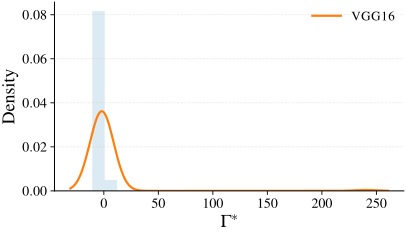

Saved: gamma_density_per_model_paper.pdf


In [13]:
from pathlib import Path
import sys

HELPER_DIR = Path(PLOT_DIR)
if str(HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(HELPER_DIR))

from gamma_density_plot import plot_gamma_density_from_csv

CSV_PATH = HELPER_DIR / "vggnet_gamma_all_option1.csv"
OUT_PDF = HELPER_DIR / "gamma_density_imagenet_vgg16_paper.pdf"

df = plot_gamma_density_from_csv(
    csv_path=CSV_PATH,
    out_pdf=OUT_PDF,
    merge_models=True,
    merged_label="ImageNet (VGG16)",
)


In [14]:
IMAGENET_CSV_PATH = PROJECT_ROOT / "results" / "vggnet16" / "ALL_vggnet.csv"